/Users/chipbrock/quarto_temp/ipykernel_52250/451336219.py:3: UserWarning: legacy printing option can currently only be '1.13', '1.21', or `False`
  np.set_printoptions(legacy="1.25")


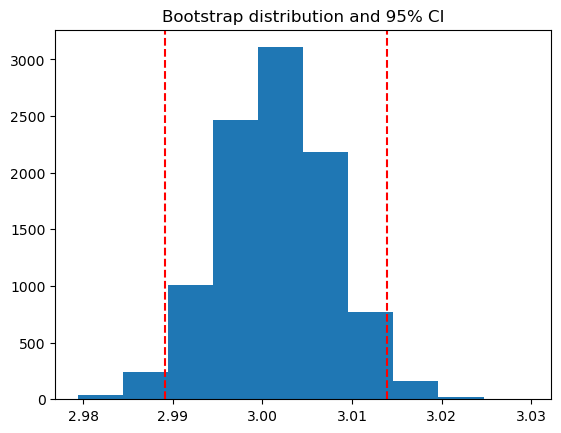

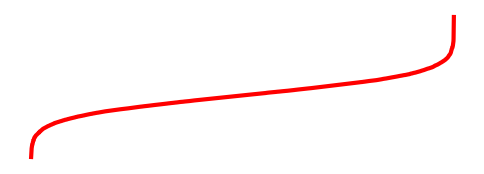

In [1]:
# Simulate some data and bootstrap the mean of the data
import numpy as np
np.set_printoptions(legacy="1.25")

import pandas as pd
import matplotlib.pyplot as plt
from myst_nb import glue

n_points = 10000
n_boots = 1000
mean, sd = (3, .2)
data = sd*np.random.randn(n_points) + mean
bootstrap_indices = np.random.randint(0, n_points, n_points*n_boots).reshape((n_boots, n_points))

# Calculate the mean of a bunch of random samples
means = data[bootstrap_indices].mean(0)
# Calculate the 95% confidence interval for the mean
clo, chi = np.percentile(means, [2.5, 97.5])

fig, ax = plt.subplots()
ax.hist(means)
for ln in [clo, chi]:
    ax.axvline(ln, ls='--', c='r')
ax.set_title("Bootstrap distribution and 95% CI")

# And a wider figure to show a timeseries
fig2, ax = plt.subplots(figsize=(6, 2))
ax.plot(np.sort(means), lw=3, c='r')
ax.set_axis_off()

plt.show()

glue("boot_fig", fig, display=False)
glue("sorted_means_fig", fig2, display=False)
